# A tour of the LINCS L1000 Phase II data (GSE70138)

What every file in `data/raw/` is, how the files connect, and what the measurements look like.
Each section loads one piece and plots it. Run top to bottom; nothing here writes to `data/`.

**Prerequisite:** `uv run python -m pertpred.data` and `uv run python -m pertpred.split` (they build
the landmark matrix and split in `data/pre-processed/`). Section 9 additionally needs the
decompressed Level 3 file and is skipped if it is absent.

**Contents**
1. The files at a glance
2. How the files connect
3. `gene_info` — which genes, landmark vs inferred
4. `cell_info` — the cell lines
5. `pert_info` — the perturbagens and their structures
6. `sig_info` — one row per consensus signature (Level 5)
7. `inst_info` — one row per well (Level 3), and replicates
8. The GCTX matrix format and what one signature looks like
9. Level 3 vs Level 5: raw expression vs differential z-scores
10. Signal vs noise: most signatures look like vehicle
11. Dose response and cell-line specificity
12. Replicate reproducibility: the noise ceiling
13. Global structure (PCA)
14. Chemistry: how new are the test compounds?
15. Takeaways

In [1]:
import numpy as np
import pandas as pd
import h5py
from matplotlib.colors import LinearSegmentedColormap

from pertpred import config as C
from pertpred.data import load_signatures
from pertpred.plotstyle import setup, plt, SERIES, NEUTRAL, INK2
%matplotlib inline

setup()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
# LINCS uses -666 as its missing-value code
read = lambda p: pd.read_csv(p, sep="\t", na_values=["-666", "-666.0"], low_memory=False)
DIVERGING = LinearSegmentedColormap.from_list("bluegrayred", ["#2a78d6", "#f0efec", "#e34948"])
print("raw data:", C.DATA_DIR)
print("cache:   ", C.CACHE_DIR)

raw data: /home/yassir/Projects/pert_predictor/data/raw
cache:    /home/yassir/Projects/pert_predictor/data/pre-processed


## 1. The files at a glance

| file | rows x cols | one row is | what it is for |
|---|---|---|---|
| `Level3_INF_mlr12k_n345976x12328.gctx.gz` | 345,976 x 12,328 | one **well** (instance) | normalized log2 expression of every gene in every well, before any comparison to controls |
| `Level5_COMPZ_n118050x12328.gctx.gz` | 118,050 x 12,328 | one **signature** | consensus differential z-scores: replicate wells of the same condition collapsed into one vector ("how did this perturbation change each gene?") |
| `gene_info` | 12,328 | gene | gene id, symbol, and whether it is a measured **landmark** (978) or computationally **inferred** |
| `cell_info` | 98 | cell line | tissue of origin, subtype, donor, genetic modifications |
| `pert_info` | 2,170 | perturbagen | name, SMILES, InChIKey of each compound / reagent |
| `sig_info` | 118,050 | signature | metadata for each Level 5 column: perturbagen, cell, dose, time, and which wells were collapsed (`distil_id`) |
| `inst_info` | 345,976 | well | metadata for each Level 3 column: plate, well, dose, time, perturbagen |
| `SHA512SUMS.txt` | | file | checksums from GEO (also lists Level 1/2/4 files that are *not* supplied) |

Processing levels in L1000: Level 1 raw fluorescence -> Level 2 landmark expression ->
**Level 3** normalized + inferred expression (supplied) -> Level 4 per-well z-scores vs the plate
(not supplied) -> **Level 5** replicate-consensus z-scores (supplied).

In [2]:
files = sorted(p for p in C.DATA_DIR.iterdir() if p.is_file())
pd.DataFrame({"file": [f.name for f in files], "size_MB": [round(f.stat().st_size / 1e6, 1) for f in files]})

,file,size_MB
0,GSE70138_Broad_LINCS_Level3_INF_mlr12k_n345976...,13540.5
1,GSE70138_Broad_LINCS_Level5_COMPZ_n118050x1232...,5365.2
2,GSE70138_Broad_LINCS_cell_info_2017-04-28.txt.gz,0.0
3,GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz,0.2
4,GSE70138_Broad_LINCS_inst_info_2017-03-06.txt.gz,4.8
5,GSE70138_Broad_LINCS_pert_info_2017-03-06.txt.gz,0.1
6,GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz,1.9


## 2. How the files connect

```
                    pert_info            cell_info
                  (pert_id ->          (cell_id ->
               SMILES, InChIKey)     tissue, subtype)
                        \                 /
                         \               /
 inst_info  --- distil_id (several wells) --->  sig_info
 (1 row / well)                                 (1 row / signature)
     | inst_id = column id                          | sig_id = column id
     v                                              v
 Level 3 matrix (wells x genes)        Level 5 matrix (signatures x genes)
     \______________________  gene_info  __________________/
                        pr_gene_id = row id of both matrices
```

* A **signature** (Level 5) is built from 2-6 replicate **wells** (Level 3). `sig_info.distil_id`
  lists them, separated by `|`.
* `pert_id` links both metadata tables to `pert_info`; `cell_id` links to `cell_info`.
* Matrices are indexed by ids, not positions: always align by id.

## 3. `gene_info` — 978 measured landmarks, the rest inferred

L1000 measures only ~1,000 "landmark" transcripts with a bead assay. The other ~11,000 genes are
**predicted** from the landmarks by a linear model trained on reference data.

The two flags are **nested, not exclusive**. `pr_is_lm = 1` marks the 978 measured landmarks.
`pr_is_bing = 1` marks the "BING" (best inferred genes) space, which despite its name *includes* the
landmarks: BING = 978 landmarks + 9,196 inferred genes the model predicts well = 10,174 genes. The
remaining 2,154 inferred genes are poorly predicted.

```python
genes[genes.pr_is_lm == 1]                              # 978 measured landmarks
genes[(genes.pr_is_bing == 1) & (genes.pr_is_lm == 0)]  # 9,196 well-inferred genes only
genes[genes.pr_is_bing == 0]                            # 2,154 poorly inferred genes
```

In [3]:
genes = read(C.GENE_INFO)
display(genes.head())
print(pd.crosstab(genes["pr_is_lm"].map({1: "landmark", 0: "inferred"}),
                  genes["pr_is_bing"].map({1: "BING", 0: "not BING"}), margins=True))

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


pr_is_bing   BING  not BING    All
pr_is_lm                          
inferred     9196      2154  11350
landmark      978         0    978
All         10174      2154  12328


Because inferred genes are linear functions of the landmarks, they add no independent information.
This project models the 978 landmarks only.

## 4. `cell_info` — the cell lines

In [4]:
cells = read(C.CELL_INFO)
display(cells[["cell_id", "cell_type", "primary_site", "subtype", "sample_type", "modification"]].head(12))
print(f"{len(cells)} cell lines; primary sites:", cells["primary_site"].value_counts().head(8).to_dict())

,cell_id,cell_type,primary_site,subtype,sample_type,modification
0,A375,cell line,skin,malignant melanoma,tumor,NaN
1,A375.311,cell line,skin,malignant melanoma,tumor,genetically modified to stably express Cas9 pr...
2,A549,cell line,lung,non small cell lung cancer| carcinoma,tumor,NaN
3,A549.311,cell line,lung,non small cell lung cancer| carcinoma,tumor,genetically modified to stably express Cas9 p...
4,A673,cell line,bone,ewing's sarcoma,tumor,NaN
5,AGS,cell line,stomach,adenocarcinoma,tumor,NaN
6,BT20,cell line,breast,carcinoma,tumor,NaN
7,CL34,cell line,large intestine,colorectal adenocarcinoma,tumor,NaN
8,CORL23,cell line,lung,non small cell lung cancer| large cell carcinoma,tumor,NaN
9,COV644,cell line,ovary,carcinoma| epithelial-mucinous,tumor,NaN


98 cell lines; primary sites: {'large intestine': 17, 'lung': 13, 'breast': 9, 'haematopoietic and lymphoid tissue': 8, 'skin': 6, 'ovary': 6, 'kidney': 6, 'prostate': 5}


## 5. `pert_info` — the perturbagens

`pert_type`: `trt_cp` = compound, `trt_xpr` = CRISPR knockout, `ctl_vehicle` = DMSO, `ctl_vector`
= empty CRISPR vector, `ctl_untrt` = untreated. This is the only file with chemical structure
(SMILES) — it was missing from the local copy and was re-downloaded from GEO (checksum verified).

In [5]:
perts = read(C.PERT_INFO)
print(perts["pert_type"].value_counts().to_dict())
display(perts[perts["pert_type"] == "trt_cp"].sample(5, random_state=1))

{'trt_cp': 1796, 'trt_xpr': 353, 'ctl_vector': 19, 'ctl_vehicle': 1, 'ctl_untrt': 1}


,pert_id,canonical_smiles,inchi_key,pert_iname,pert_type
1066,BRD-K66911501,Fc1cc(F)cc(c1)[C@@H]1CNC2(CCCC2)C(=O)N1CC(=O)N...,AZAANWYREOQRFB-SETSBSEESA-N,MK-3207,trt_cp
293,BRD-A16665823,Clc1ccc(CCC(Cn2ccnc2)Sc2c(Cl)cccc2Cl)cc1,SWLMUYACZKCSHZ-UHFFFAOYSA-N,butoconazole,trt_cp
1403,BRD-A34255068,COc1ccc(cc1OC1CCCC1)C1CNC(=O)C1,HJORMJIFDVBMOB-UHFFFAOYSA-N,rolipram,trt_cp
1090,BRD-K74141488,CN(C\C=C\c1ccccc1)Cc1cccc2ccccc12,OZGNYLLQHRPOBR-DHZHZOJOSA-N,naftifine,trt_cp
481,BRD-K33211335,COc1ccc2C[C@H]3[C@H]4CCCC[C@@]4(CCN3C)c2c1,MKXZASYAUGDDCJ-NJAFHUGGSA-N,dextromethorphan,trt_cp


## 6. `sig_info` — one row per Level 5 signature

`pert_idose` / `pert_itime` are the dose and time as strings (`"10.0 um"`, `"24 h"`).
`distil_id` lists the replicate wells that were collapsed into the signature.

In [6]:
sig = read(C.SIG_INFO)
display(sig.head(3))
print(sig["pert_type"].value_counts().to_dict())

,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,distil_id
0,LJP005_A375_24H:A03,DMSO,DMSO,ctl_vehicle,A375,NaN,24 h,LJP005_A375_24H_X1_B19:A03|LJP005_A375_24H_X2_...
1,LJP005_A375_24H:A04,DMSO,DMSO,ctl_vehicle,A375,NaN,24 h,LJP005_A375_24H_X1_B19:A04|LJP005_A375_24H_X2_...
2,LJP005_A375_24H:A05,DMSO,DMSO,ctl_vehicle,A375,NaN,24 h,LJP005_A375_24H_X1_B19:A05|LJP005_A375_24H_X2_...


{'trt_cp': 107404, 'ctl_vehicle': 6467, 'trt_xpr': 3882, 'ctl_vector': 209, 'ctl_untrt': 88}


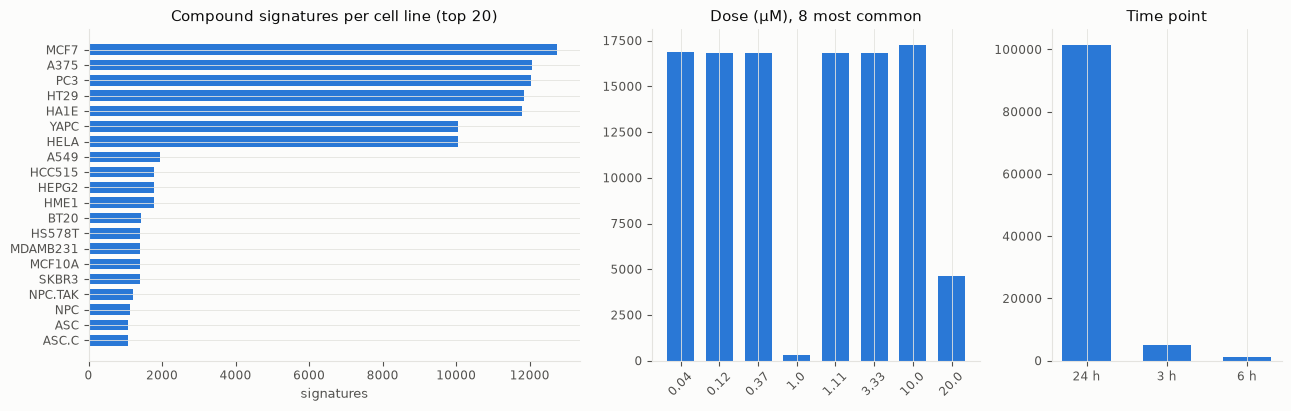

In [7]:
cp = sig[sig["pert_type"] == "trt_cp"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.5, 1, 0.7]})

top = cp["cell_id"].value_counts().head(20)[::-1]
axes[0].barh(top.index, top.values, color=SERIES[0], height=0.7)
axes[0].set_title("Compound signatures per cell line (top 20)")
axes[0].set_xlabel("signatures")

doses = cp["pert_idose"].value_counts().head(8)
doses = doses.iloc[np.argsort(doses.index.str.replace(" um", "").astype(float))]
axes[1].bar(doses.index.str.replace(" um", ""), doses.values, color=SERIES[0], width=0.7)
axes[1].set_title("Dose (µM), 8 most common")
axes[1].tick_params(axis="x", rotation=45)

times = cp["pert_itime"].value_counts()
axes[2].bar(times.index, times.values, color=SERIES[0], width=0.6)
axes[2].set_title("Time point")
for ax in axes:
    ax.grid(axis="y" if ax is not axes[0] else "x")
fig.tight_layout()

**Reading these plots.** Seven "core" cell lines (MCF7, A375, PC3, HT29, HA1E, YAPC, HELA) carry most
of the data; the rest have ~1-2k signatures each. Doses follow a 6-step ladder
(0.04 -> 10 µM, roughly 3x apart). Almost everything is 24 h.

The **20 µM** bar is almost entirely two drugs, bortezomib and MG-132: they are positive-control
wells present on every plate, not experiments. They are dropped in this project.

In [8]:
c20 = cp[cp["pert_idose"] == "20.0 um"]
print(f"20 µM signatures: {len(c20)};  by compound:", c20["pert_iname"].value_counts().head(4).to_dict())
per_cmp = cp.groupby("pert_id").size()
print(f"signatures per compound: median {per_cmp.median():.0f}  (typically 7 cell lines x 6 doses = 42)")

20 µM signatures: 4607;  by compound: {'MG-132': 2310, 'bortezomib': 2297}
signatures per compound: median 42  (typically 7 cell lines x 6 doses = 42)


## 7. `inst_info` — one row per well, and how replicates work

A plate id such as `REP.A001_A375_24H_X1_B19` reads: batch `REP.A001`, cell line `A375`, time
`24H`, replicate plate `X1`, bead batch `B19`. The same compound layout is run on replicate
plates X1/X2/X3; the three wells at the same position become one signature.

In [9]:
inst = read(C.INST_INFO)
display(inst.head(3))
example = sig[(sig["pert_iname"] == "vorinostat") & (sig["cell_id"] == "MCF7") & (sig["pert_idose"] == "10.0 um") & (sig["pert_itime"] == "24 h")].iloc[0]
wells = example["distil_id"].split("|")
print("signature:", example["sig_id"], "->", len(wells), "replicate wells")
display(inst.set_index("inst_id").loc[wells, ["det_plate", "det_well", "pert_iname", "pert_dose", "pert_time"]])

,inst_id,cell_id,det_plate,det_well,pert_mfc_id,pert_dose,pert_dose_unit,pert_id,pert_iname,pert_type,pert_time,pert_time_unit
0,LJP005_A375_24H_X1_B19:A03,A375,LJP005_A375_24H_X1_B19,A03,DMSO,NaN,NaN,DMSO,DMSO,ctl_vehicle,24.0,h
1,LPROT001_A375_6H_X1_B20:B03,A375,LPROT001_A375_6H_X1_B20,B03,DMSO,NaN,NaN,DMSO,DMSO,ctl_vehicle,6.0,h
2,LPROT001_A375_6H_X1_B20:B05,A375,LPROT001_A375_6H_X1_B20,B05,DMSO,NaN,NaN,DMSO,DMSO,ctl_vehicle,6.0,h


signature: LJP007_MCF7_24H:A03 -> 3 replicate wells


,det_plate,det_well,pert_iname,pert_dose,pert_time
inst_id,,,,,
LJP007_MCF7_24H_X1_B20:A03,LJP007_MCF7_24H_X1_B20,A03,vorinostat,10.0,24.0
LJP007_MCF7_24H_X2_B20:A03,LJP007_MCF7_24H_X2_B20,A03,vorinostat,10.0,24.0
LJP007_MCF7_24H_X3_B20:A03,LJP007_MCF7_24H_X3_B20,A03,vorinostat,10.0,24.0


In [10]:
n_rep = sig["distil_id"].str.count(r"\|") + 1
wells_per_plate = inst.groupby("det_plate").size()
print("replicate wells per signature:", n_rep.value_counts().sort_index().to_dict())
print(f"wells per plate: median {wells_per_plate.median():.0f} (384-well plates); plates: {len(wells_per_plate)}")
print("DMSO wells per plate (median):", inst[inst.pert_type == "ctl_vehicle"].groupby("det_plate").size().median())

replicate wells per signature: {1: 2125, 2: 7470, 3: 106333, 4: 1042, 5: 379, 6: 701}
wells per plate: median 372 (384-well plates); plates: 948
DMSO wells per plate (median): 20.0


## 8. The GCTX format, and what one signature looks like

`.gctx` is HDF5: one big matrix plus id arrays. The matrix is stored **transposed** relative to the
"genes x samples" convention: shape is (samples, genes).

In [11]:
with h5py.File(C.LEVEL5_GCTX, "r") as f:
    f.visititems(lambda name, obj: print(f"{name:22s} {obj.shape} {obj.dtype}") if isinstance(obj, h5py.Dataset) else None)

0/DATA/0/matrix        (118050, 12328) float32
0/META/COL/id          (118050,) |S23
0/META/ROW/id          (12328,) |S9


The pipeline (`pertpred.data`) extracts the 978 landmark columns once into a NumPy matrix
(`landmark_z.npy`, 118,050 x 978) with an aligned metadata table. Below: the vorinostat signature
from section 7 next to a DMSO signature from the same cell line.

most up:   HMOX1 (+10.0), INSIG1 (+10.0), FOXO4 (+9.8), NPC1 (+9.8), STX1A (+9.7), PLA2G15 (+9.1)
most down: SPDEF (-10.0), UGDH (-9.6), NPEPL1 (-8.9), XBP1 (-8.7), ADI1 (-8.6), CCND1 (-8.4)


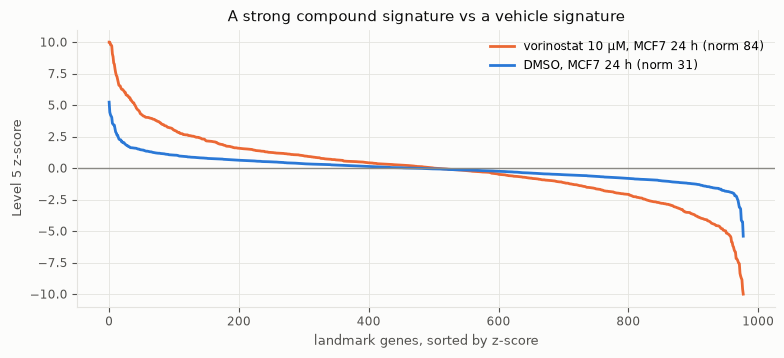

In [12]:
sigs, Y, lm_genes = load_signatures()
symbol = lm_genes["pr_gene_symbol"].to_numpy()
row_of = pd.Series(np.arange(len(sigs)), index=sigs["sig_id"])

z = np.asarray(Y[row_of[example["sig_id"]]])
dmso_id = sigs[(sigs.pert_type == "ctl_vehicle") & (sigs.cell_id == "MCF7") & (sigs.time_h == 24)]["sig_id"].iloc[0]
z0 = np.asarray(Y[row_of[dmso_id]])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(np.sort(z)[::-1], color=SERIES[1], label=f"vorinostat 10 µM, MCF7 24 h (norm {np.linalg.norm(z):.0f})")
ax.plot(np.sort(z0)[::-1], color=SERIES[0], label=f"DMSO, MCF7 24 h (norm {np.linalg.norm(z0):.0f})")
ax.axhline(0, color=NEUTRAL, lw=1)
ax.set_xlabel("landmark genes, sorted by z-score")
ax.set_ylabel("Level 5 z-score")
ax.set_title("A strong compound signature vs a vehicle signature")
ax.legend(loc="upper right")
order = np.argsort(z)
print("most up:  ", ", ".join(f"{symbol[i]} ({z[i]:+.1f})" for i in order[::-1][:6]))
print("most down:", ", ".join(f"{symbol[i]} ({z[i]:+.1f})" for i in order[:6]))

A z-score of +5 means the gene went up by ~5 robust standard deviations relative to the other wells
on its plate. The DMSO "signature" is what pure noise looks like through the same pipeline.

## 9. Level 3 vs Level 5: raw expression vs differential z-scores

Level 3 is log2 expression per well. Raw expression is dominated by each gene's baseline level:
even a strongly treated well looks broadly like the DMSO wells on its plate, and a typical treated
well is almost indistinguishable from them. Level 5 removes that baseline and keeps only the change.
(Skipped if `level3.gctx` has not been decompressed into the cache.)

plate LJP007_MCF7_24H_X1_B20: 355 compound wells; their raw-expression correlation with the plate's DMSO median: median r = 0.956 (vorinostat 10 µM: 0.829, lower than 97% of wells)


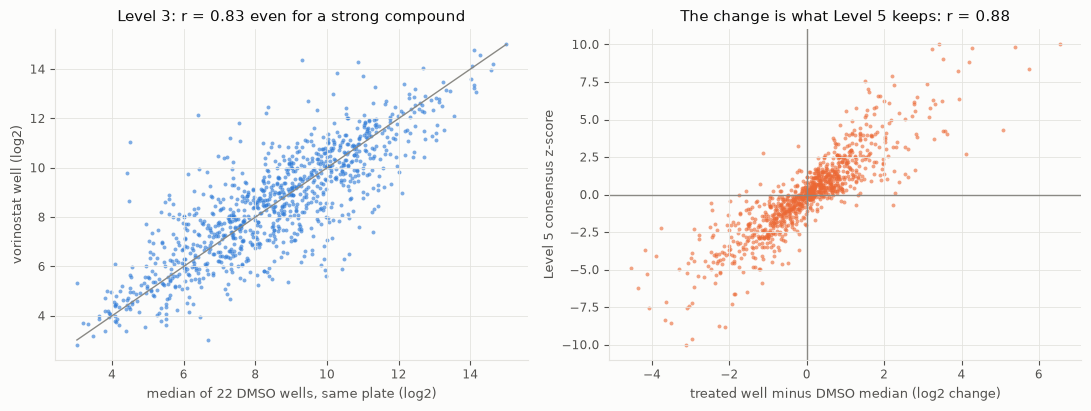

In [13]:
if not C.LEVEL3_GCTX.exists():
    print(f"skipped: decompress first with\n  gzip -dc {C.LEVEL3_GZ} > {C.LEVEL3_GCTX}")
else:
    plate = inst.set_index("inst_id").loc[wells[0], "det_plate"]
    on_plate = inst[inst.det_plate == plate]
    dmso_wells = on_plate[on_plate.pert_type == "ctl_vehicle"]["inst_id"].tolist()
    with h5py.File(C.LEVEL3_GCTX, "r") as f:
        col_ids = f["0/META/COL/id"][:].astype(str)
        row_ids = f["0/META/ROW/id"][:].astype(str)
        pos = pd.Series(np.arange(len(col_ids)), index=col_ids)
        gpos = pd.Series(np.arange(len(row_ids)), index=row_ids).loc[lm_genes["pr_gene_id"].astype(str)].to_numpy()
        want = sorted(pos.loc[on_plate["inst_id"]])            # every well on this plate
        block = f["0/DATA/0/matrix"][want, :][:, gpos]          # (wells, 978) log2 expression
    lookup = dict(zip(want, block))
    treated = lookup[pos[wells[0]]]
    dmso_med = np.median(np.stack([lookup[pos[w]] for w in dmso_wells]), axis=0)
    trt_wells = on_plate[on_plate.pert_type == "trt_cp"]["inst_id"]
    r_all = np.array([np.corrcoef(lookup[pos[w]], dmso_med)[0, 1] for w in trt_wells])
    print(f"plate {plate}: {len(trt_wells)} compound wells; their raw-expression correlation with the "
          f"plate's DMSO median: median r = {np.median(r_all):.3f} (vorinostat 10 µM: "
          f"{np.corrcoef(treated, dmso_med)[0, 1]:.3f}, lower than {100 * (r_all > np.corrcoef(treated, dmso_med)[0, 1]).mean():.0f}% of wells)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].scatter(dmso_med, treated, s=8, color=SERIES[0], alpha=0.6, linewidths=0)
    lim = [dmso_med.min(), dmso_med.max()]
    axes[0].plot(lim, lim, color=NEUTRAL, lw=1)
    axes[0].set_xlabel(f"median of {len(dmso_wells)} DMSO wells, same plate (log2)")
    axes[0].set_ylabel("vorinostat well (log2)")
    axes[0].set_title(f"Level 3: r = {np.corrcoef(dmso_med, treated)[0, 1]:.2f} even for a strong compound")

    diff = treated - dmso_med
    axes[1].scatter(diff, z, s=8, color=SERIES[1], alpha=0.6, linewidths=0)
    axes[1].axhline(0, color=NEUTRAL, lw=1); axes[1].axvline(0, color=NEUTRAL, lw=1)
    axes[1].set_xlabel("treated well minus DMSO median (log2 change)")
    axes[1].set_ylabel("Level 5 consensus z-score")
    axes[1].set_title(f"The change is what Level 5 keeps: r = {np.corrcoef(diff, z)[0, 1]:.2f}")
    fig.tight_layout()

## 10. Signal vs noise: most signatures look like vehicle

From here on: compound signatures as used in the project (`pertpred.task.load_task`: plate controls
removed, z clipped at ±10). The signature **norm** (length of the 978-vector) measures how much a
treatment changed expression. DMSO signatures show how large a norm noise alone produces.

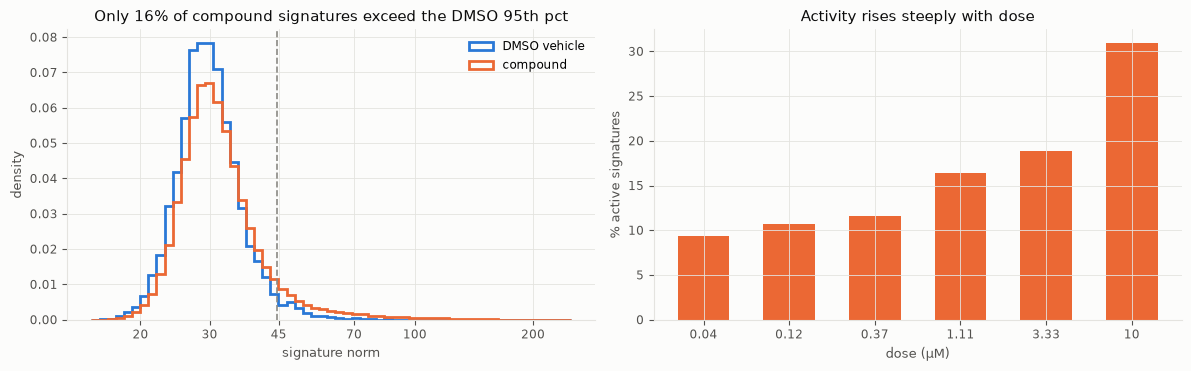

In [14]:
from pertpred.task import load_task
from pertpred.evaluate import activity_flags

task = load_task()
meta, Yc = task.meta, task.Y
norm = np.linalg.norm(Yc, axis=1)
active = activity_flags(task, np.arange(len(meta)))
ctl_rows = np.flatnonzero((sigs.pert_type == "ctl_vehicle").to_numpy())
dmso_norm = np.linalg.norm(np.clip(np.asarray(Y[ctl_rows]), -10, 10), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
bins = np.geomspace(15, 250, 60)
axes[0].hist(dmso_norm, bins=bins, density=True, histtype="step", lw=2, color=SERIES[0], label="DMSO vehicle")
axes[0].hist(norm, bins=bins, density=True, histtype="step", lw=2, color=SERIES[1], label="compound")
axes[0].axvline(np.quantile(dmso_norm, 0.95), color=NEUTRAL, ls="--", lw=1.2)
axes[0].set_xscale("log"); axes[0].set_xticks([20, 30, 45, 70, 100, 200], ["20", "30", "45", "70", "100", "200"]); axes[0].minorticks_off()
axes[0].set_xlabel("signature norm"); axes[0].set_ylabel("density"); axes[0].legend()
axes[0].set_title(f"Only {100 * active.mean():.0f}% of compound signatures exceed the DMSO 95th pct")

by_dose = pd.Series(active).groupby(meta["dose_bin"].to_numpy()).mean().drop(20.0, errors="ignore")
axes[1].bar([f"{d:g}" for d in by_dose.index], 100 * by_dose.values, color=SERIES[1], width=0.6)
axes[1].set_xlabel("dose (µM)"); axes[1].set_ylabel("% active signatures")
axes[1].set_title("Activity rises steeply with dose")
fig.tight_layout()

At the lowest dose ~9% of signatures pass the threshold, not far from the 5% expected from noise
alone (the threshold is the DMSO 95th percentile); at 10 µM it is ~31%.

## 11. Dose response and cell-line specificity

**Dose:** the same compound across the 6-dose ladder in one cell line, for the genes it moves most.

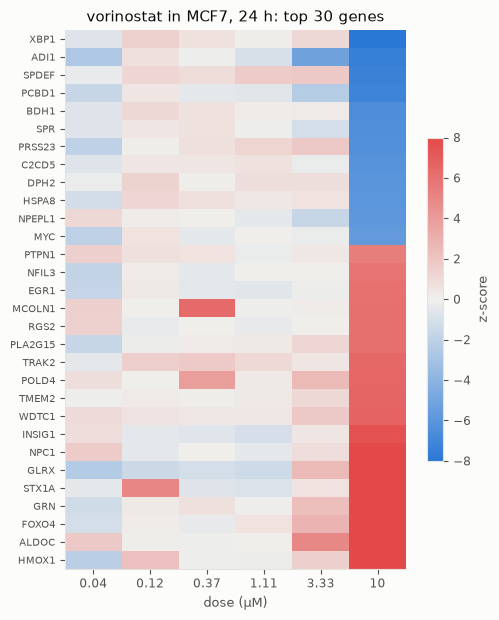

In [15]:
def signature(name, cell, dose, time=24.0):
    hit = meta[(meta.pert_iname == name) & (meta.cell_id == cell) & (meta.dose_bin == dose) & (meta.time_h == time)]
    return Yc[hit.index].mean(axis=0) if len(hit) else None

ladder = [0.04, 0.12, 0.37, 1.11, 3.33, 10.0]
mat = np.stack([signature("vorinostat", "MCF7", d) for d in ladder])
top = np.argsort(-np.abs(mat[-1]))[:30]
top = top[np.argsort(mat[-1, top])]
fig, ax = plt.subplots(figsize=(5.5, 7))
im = ax.imshow(mat[:, top].T, cmap=DIVERGING, vmin=-8, vmax=8, aspect="auto")
ax.set_xticks(range(len(ladder)), [f"{d:g}" for d in ladder]); ax.set_xlabel("dose (µM)")
ax.set_yticks(range(len(top)), symbol[top], fontsize=7.5)
ax.set_title("vorinostat in MCF7, 24 h: top 30 genes"); ax.grid(False)
fig.colorbar(im, ax=ax, label="z-score", shrink=0.6)

For vorinostat in MCF7 the response is close to all-or-nothing: nothing consistent below 3.33 µM,
then a strong signature at 10 µM. Dose is a threshold here, not a smooth dial.

**Cell line:** does a compound do the same thing in every cell line? The heatmap correlates
vorinostat's 10 µM signatures across the 7 core lines. The histogram asks the general question,
over all *active* 10 µM signatures: how similar are two signatures that share the compound (but not
the cell line), share the cell line (but not the compound), or share both (replicate plates)?
Caveat: active compounds share a generic stress / anti-proliferation response, which raises every
curve; the *gap* between the curves is the informative part.

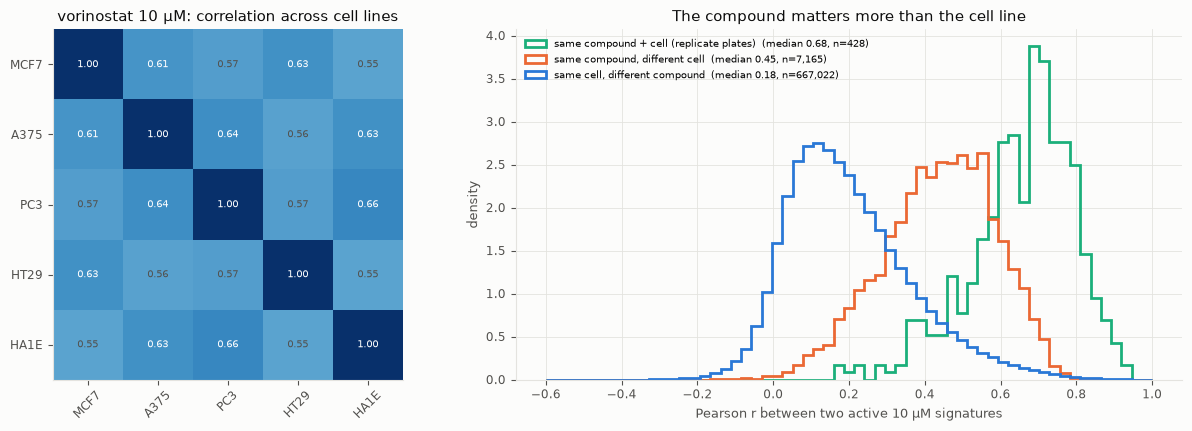

In [16]:
core = ["MCF7", "A375", "PC3", "HT29", "HA1E", "YAPC", "HELA"]
have = [c for c in core if signature("vorinostat", c, 10.0) is not None]  # not every compound was run in every line
V = np.stack([signature("vorinostat", c, 10.0) for c in have])
R = np.corrcoef(V)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [1, 1.4]})
im = axes[0].imshow(R, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(len(have)), have, rotation=45); axes[0].set_yticks(range(len(have)), have); axes[0].grid(False)
for i in range(len(have)):
    for j in range(len(have)):
        axes[0].text(j, i, f"{R[i, j]:.2f}", ha="center", va="center", fontsize=7.5, color="white" if R[i, j] > 0.6 else INK2)
axes[0].set_title("vorinostat 10 µM: correlation across cell lines")

sel = meta[(meta.dose_bin == 10.0) & (meta.time_h == 24) & meta.cell_id.isin(core) & active].reset_index()
S = np.corrcoef(Yc[sel["index"]])
iu = np.triu_indices(len(sel), 1)
same_cmp = (sel.pert_id.to_numpy()[:, None] == sel.pert_id.to_numpy()[None, :])[iu]
same_cell = (sel.cell_id.to_numpy()[:, None] == sel.cell_id.to_numpy()[None, :])[iu]
groups = {
    "same compound + cell (replicate plates)": S[iu][same_cmp & same_cell],
    "same compound, different cell": S[iu][same_cmp & ~same_cell],
    "same cell, different compound": S[iu][~same_cmp & same_cell],
}
bins = np.linspace(-0.6, 1, 60)
for (label, vals), color in zip(groups.items(), [SERIES[2], SERIES[1], SERIES[0]]):
    axes[1].hist(vals, bins=bins, density=True, histtype="step", lw=2, color=color, label=f"{label}  (median {np.median(vals):.2f}, n={len(vals):,})")
axes[1].set_xlabel("Pearson r between two active 10 µM signatures"); axes[1].set_ylabel("density")
axes[1].set_title("The compound matters more than the cell line"); axes[1].legend(fontsize=7.5, loc="upper left")
fig.tight_layout()

## 12. Replicate reproducibility: the noise ceiling

Some conditions were run on more than one batch of plates. Two Level 5 signatures of the *same*
condition show how well the measurement can predict itself — an upper bound for any model.

4456 repeated conditions; median replicate r = 0.19
median r by weaker-signature norm quartile: [0.07, 0.11, 0.26, 0.65]


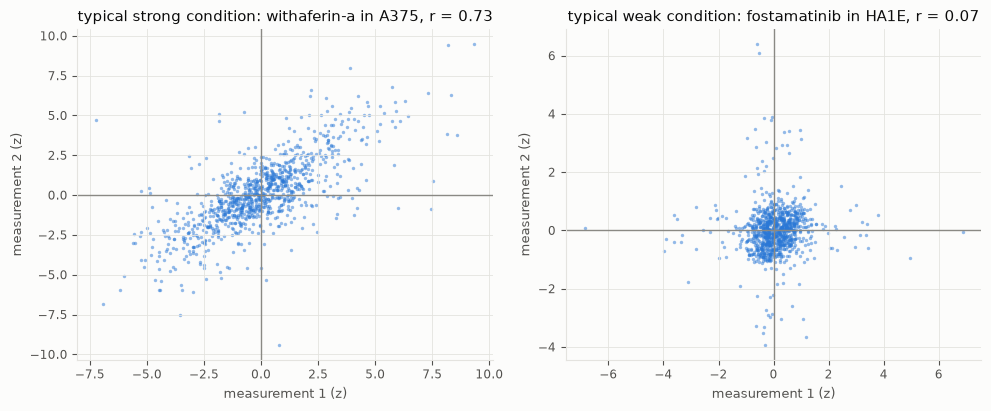

In [17]:
from pertpred.eda import replicate_pairs
from pertpred.metrics import rowwise_pearson

pairs = replicate_pairs(task)
a, b = Yc[pairs.i.to_numpy()], Yc[pairs.j.to_numpy()]
pairs["r"] = rowwise_pearson(a, b)
pairs["min_norm"] = np.minimum(norm[pairs.i], norm[pairs.j])
def typical(sub):  # the pair whose r is closest to its group's median
    return sub.iloc[(sub.r - sub.r.median()).abs().argmin()]
strong = typical(pairs[pairs.min_norm >= pairs.min_norm.quantile(0.9)])
weak = typical(pairs[pairs.min_norm <= pairs.min_norm.quantile(0.25)])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=False)
for ax, p, title in [(axes[0], strong, "typical strong condition"), (axes[1], weak, "typical weak condition")]:
    i, j = int(p.i), int(p.j)  # a row of a mixed-dtype frame comes back as floats
    ax.scatter(Yc[i], Yc[j], s=6, color=SERIES[0], alpha=0.5, linewidths=0)
    ax.axhline(0, color=NEUTRAL, lw=1); ax.axvline(0, color=NEUTRAL, lw=1)
    ax.set_xlabel("measurement 1 (z)"); ax.set_ylabel("measurement 2 (z)")
    ax.set_title(f"{title}: {meta.pert_iname[i]} in {meta.cell_id[i]}, r = {p.r:.2f}")
fig.tight_layout()
print(f"{len(pairs)} repeated conditions; median replicate r = {pairs.r.median():.2f}")
print("median r by weaker-signature norm quartile:",
      [round(float(v), 2) for v in pairs.groupby(pd.qcut(pairs.min_norm, 4), observed=True).r.median()])

## 13. Global structure (PCA of active signatures)

Projecting active compound signatures on their first two principal components, colored by dose.

PC1 top genes (+): TXLNA, CLTC, PCNA, HSPA8, TIMM9, CCNB2, RNPS1, RAE1
PC1 top genes (-): HIST2H2BE, PTK2B, LYN, ITFG1, GPC1, C2CD2L, TERT, TBXA2R


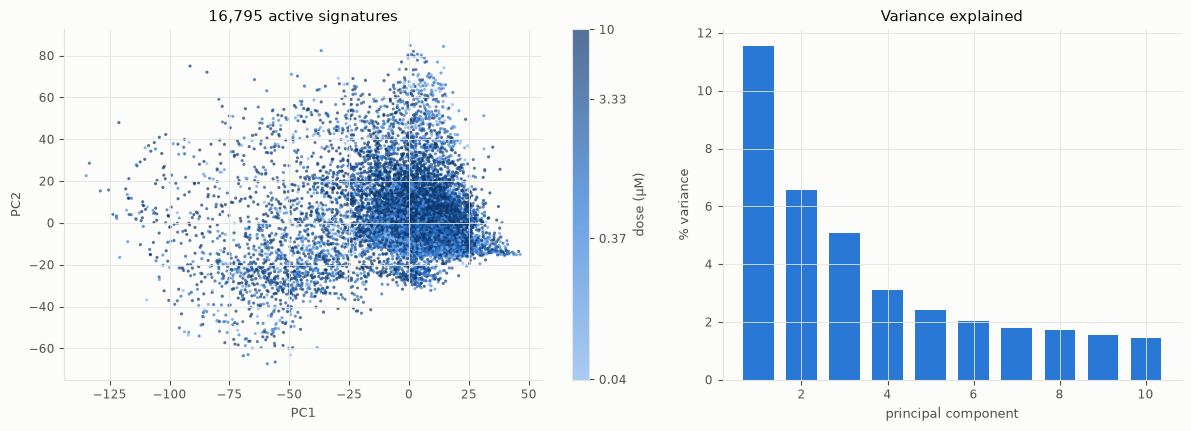

In [18]:
from sklearn.decomposition import PCA

act = np.flatnonzero(active & (meta.dose_bin.to_numpy() <= 10))
pca = PCA(n_components=10, random_state=0).fit(Yc[act])
P = pca.transform(Yc[act])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
ramp = LinearSegmentedColormap.from_list("dose", ["#86b6ef", "#2a78d6", "#0d366b"])  # lightest step still visible on the surface
sc = axes[0].scatter(P[:, 0], P[:, 1], c=np.log10(meta.dose_bin.to_numpy()[act]), cmap=ramp, s=5, alpha=0.7, linewidths=0, vmin=-1.4, vmax=1.0)
cb = fig.colorbar(sc, ax=axes[0]); cb.set_label("dose (µM)"); cb.set_ticks(np.log10([0.04, 0.37, 3.33, 10]), labels=["0.04", "0.37", "3.33", "10"])
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].set_title(f"{len(act):,} active signatures")
axes[1].bar(range(1, 11), 100 * pca.explained_variance_ratio_, color=SERIES[0], width=0.7)
axes[1].set_xlabel("principal component"); axes[1].set_ylabel("% variance"); axes[1].set_title("Variance explained")
fig.tight_layout()
loadings = pca.components_[0]
print("PC1 top genes (+):", ", ".join(symbol[np.argsort(-loadings)[:8]]))
print("PC1 top genes (-):", ", ".join(symbol[np.argsort(loadings)[:8]]))

PC1 (~12% of variance) is a proliferation axis: cell-cycle and replication genes (PCNA, CCNB2) load
on it, and high-dose signatures spread toward the side where those genes go *down* — a generic
"cells stopped dividing" response shared by many unrelated compounds. No single component dominates,
so most of what distinguishes compounds is spread over many smaller directions.

## 14. Chemistry: how new are the test compounds?

The project holds out whole compounds. For each val/test compound, the Tanimoto similarity (Morgan
fingerprints) to its *most similar* training compound measures how novel it is. Below that: a
data pitfall found while preparing this notebook.

{'test': 270, 'train': 1340, 'val': 184}


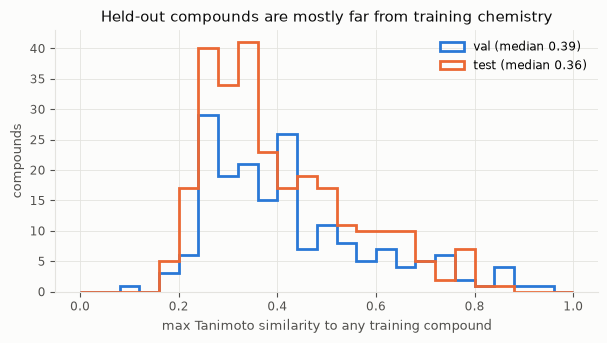

In [19]:
cmp = meta.drop_duplicates("pert_id")
fig, ax = plt.subplots(figsize=(7, 3.4))
bins = np.linspace(0, 1, 26)
for split, color in [("val", SERIES[0]), ("test", SERIES[1])]:
    ax.hist(cmp.loc[cmp.split == split, "max_tani_train"].dropna(), bins=bins, histtype="step", lw=2, color=color, label=f"{split} (median {cmp.loc[cmp.split == split, 'max_tani_train'].median():.2f})")
ax.set_xlabel("max Tanimoto similarity to any training compound"); ax.set_ylabel("compounds")
ax.set_title("Held-out compounds are mostly far from training chemistry"); ax.legend()
print(cmp.groupby("split").size().to_dict())

In [20]:
# Pitfall: salts / prodrugs of one drug under different names are not merged by InChIKey skeleton.
salts = r"[-\s](hydrochloride|dihydrochloride|hcl|citrate|mesylate|maleate|tartrate|sulfate|phosphate|sodium|acetate|fumarate|besylate|tosylate|succinate|bromide|chloride|hydrate)$"
base = cmp["pert_iname"].str.lower().str.replace(salts, "", regex=True)
dup = cmp.assign(base=base).groupby("base").filter(lambda g: g["group_id"].nunique() > 1)
display(dup[["base", "pert_iname", "split", "inchi_key"]].sort_values("base"))

,base,pert_iname,split,inchi_key
35490,dexamethasone,dexamethasone,train,UREBDLICKHMUKA-HIERVMNKSA-N
63175,dexamethasone,dexamethasone-acetate,train,AKUJBENLRBOFTD-HIBZCRSPSA-N
70756,dexamethasone,dexamethasone,train,UREBDLICKHMUKA-UHFFFAOYSA-N
25829,estramustine,estramustine-phosphate,val,ADFOJJHRTBFFOF-RBRWEJTLSA-N
49452,estramustine,estramustine,train,FRPJXPJMRWBBIH-ZZSVNSIZSA-N
40186,ixazomib,ixazomib-citrate,val,YTXSYWAKVMZICI-PVCZSOGJSA-N
54291,ixazomib,ixazomib,test,MXAYKZJJDUDWDS-LBPRGKRZSA-N


Three drug pairs are the same active molecule under two names (salt / ester forms). One pair sits
in train + val and one in val + test; **none links train to test**, so test scores are not leaked,
but val-based model selection saw one near-duplicate of a test compound.

## 15. Takeaways

1. **Two matrices, five metadata tables.** Level 3 = per-well expression; Level 5 = per-condition
   differential z-scores. `sig_info.distil_id` links a signature to its wells.
2. **978 genes are measured**; the other 11,350 are inferred from them.
3. **The design is unbalanced:** 7 core cell lines, a 6-dose ladder, mostly 24 h; 20 µM is plate
   controls.
4. **Most signatures are noise:** only ~16% beat the DMSO 95th percentile, and activity is mostly a
   high-dose phenomenon.
5. **Reproducibility depends on signal:** replicate correlation ~0.1 for weak conditions,
   ~0.6-0.7 for strong ones — a hard ceiling for any model.
6. **Compound beats cell line:** the same compound in different cell lines looks more alike than
   different compounds in the same cell line, which is what makes compound-level prediction
   possible at all.
7. **Held-out compounds are chemically novel** (median nearest-train Tanimoto ~0.36), and a few
   salt/prodrug pairs are a residual naming pitfall.